In [40]:
# --------------------------------------------------------------
#  Car classification with CNNs using PyTorch
# --------------------------------------------------------------

import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import os
import time
from datetime import timedelta

# --------------------------  SEED  ---------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)          # for multi-GPU
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
# --------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print("Using seed:", SEED)
# --------------------------------------------------------------

Using device: cuda
Using seed: 42


In [41]:
# -----------------------  PARAMETERS  ------------------------
BATCH_SIZE       = 32   # batch size
IMAGE_SIZE       = 224  # 224x224 images
BASE_LR          = 1e-3 # base learning rate
TRANSFER_LR      = 1e-4 # transfer learning learning rate
WEIGHT_DECAY     = 1e-4 # weight decay for optimizer
WARMPUP_EPOCHS   = 3    # number of warm-up epochs
EPOCHS_BASE      = 50   # number of training epochs
EPOCHS_TL        = 10   # number of transfer learning epochs
PATIENCE         = 8   # early stopping patience
# --------------------------------------------------------------
DATA_ROOT        = "./cars_dataset"
SELECTED_CLASSES = ["chevrolet-spark", "chevrolet-aveo", "golf", "polo", "toyota-corolla", "octavia", "logan"]
# --------------------------------------------------------------
TRAIN_TEST_SPLIT = 0.8  # 80%-20% train/test split
TRAIN_VAL_SPLIT  = 0.8  # 80%-20% train/val split
# --------------------------------------------------------------


| #  | Name of class         | Number of files |
|----|-----------------------|-----------------|
| 1  | bmw-serie-1           | 82              |
| 2  | chevrolet-spark       | 108             |
| 3  | chevrolet-aveo        | 129             |
| 4  | clio                  | 344             |
| 5  | duster                | 280             |
| 6  | golf                  | 160             |
| 7  | hyundai-i10           | 130             |
| 8  | hyundai-tucson        | 128             |
| 9  | logan                 | 112             |
| 10 | megane                | 280             |
| 11 | mercedes-class-a      | 84              |
| 12 | nemo-citroen          | 80              |
| 13 | octavia               | 156             |
| 14 | picanto               | 178             |
| 15 | polo                  | 132             |
| 16 | sandero               | 260             |
| 17 | seat-ibiza            | 100             |
| 18 | symbol                | 158             |
| 19 | toyota-corolla        | 150             |
| 20 | volkswagen-tiguan     | 184             |

In [42]:
# -----------------------  TRANSFORMS  ------------------------

# https://docs.pytorch.org/vision/stable/transforms.html#torchvision.transforms.Normalize
# for normalization, we use the standard ImageNet values
mean_values = [0.485, 0.456, 0.406]  # ImageNet mean values for normalization
std_values  = [0.229, 0.224, 0.225]  # ImageNet std values for normalization

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),  # redimensiona la imagen
    transforms.RandomHorizontalFlip(p=0.5),  # voltea horizontalmente con probabilidad 0.5
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),  # recorte y escalado aleatorio
    transforms.RandomRotation(degrees=10),  # rotación a la imagen aleatoria
    transforms.ColorJitter(hue=0.15, brightness=0.2, contrast=0.2, saturation=0.2),  # altera color/contraste/tono
    transforms.ToTensor(),  # convierte PIL->Tensor y normaliza rango [0,1]
    transforms.Normalize(mean=mean_values,  # normaliza con medias de ImageNet
                         std=std_values),  # desviaciones estándar de ImageNet
])

test_transform = transforms.Compose([  # transformaciones para validación/prueba (determinísticas)
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),  # redimensiona al tamaño objetivo
    transforms.ToTensor(),  # convierte a tensor
    transforms.Normalize(mean=mean_values,  # normaliza con medias ImageNet
                         std=std_values),  # normaliza con std ImageNet
])

# --------------------------------------------------------------

In [43]:
from PIL import Image

class ToyotaDataset(Dataset):
    def __init__(self, image_paths, labels, class_to_idx, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        
        img = Image.open(img_path).convert('RGB')
        
        if self.transform:
            img = self.transform(img)
            
        return img, label

In [44]:
from sklearn.model_selection import train_test_split
import glob

def create_datasets(root_dir, selected_classes, train_transform, test_transform):
    all_paths = []
    all_labels = []
    
    class_to_idx = {cls_name: i for i, cls_name in enumerate(selected_classes)}
    
    print(f"Loading specific classes: {selected_classes}...")

    for cls_name in selected_classes:
        class_dir = os.path.join(root_dir, cls_name)
        
        # glob for png, jpg, ...
        files = glob.glob(os.path.join(class_dir, "*.*")) 
        files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
        
        if len(files) == 0:
            print(f"Warning: No images found for {cls_name}")
            continue
            
        all_paths.extend(files)
        all_labels.extend([class_to_idx[cls_name]] * len(files))
        
        print(f"Found {len(files)} images for class '{cls_name}'")

    print(f"Total images found: {len(all_paths)}")

    # train-test split
    train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
        all_paths, all_labels, 
        test_size=1-TRAIN_TEST_SPLIT, 
        stratify=all_labels,
        random_state=SEED
    )

    # train-val split
    train_paths, val_paths, train_labels, val_labels = train_test_split(
        train_val_paths, train_val_labels, 
        test_size=1-TRAIN_VAL_SPLIT,
        stratify=train_val_labels,
        random_state=SEED
    )

    train_ds = ToyotaDataset(train_paths, train_labels, class_to_idx, transform=train_transform)
    val_ds   = ToyotaDataset(val_paths, val_labels, class_to_idx, transform=test_transform)
    test_ds  = ToyotaDataset(test_paths, test_labels, class_to_idx, transform=test_transform)

    return train_ds, val_ds, test_ds

In [45]:
train_set, val_set, test_set = create_datasets(
    root_dir=DATA_ROOT,
    selected_classes=SELECTED_CLASSES,
    train_transform=train_transform,
    test_transform=test_transform
)

# 3. Verify the Balance (Optional check)
from collections import Counter
print("\n--- Distribution Check ---")
print(f"Train size: {len(train_set)}")
print(f"Validation size:   {len(val_set)}")
print(f"Test size:  {len(test_set)}")
print("Test Set Class Counts:", sorted(Counter([y for _, y in test_set]).items()))

# 4. Create Loaders
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

Loading specific classes: ['chevrolet-spark', 'chevrolet-aveo', 'golf', 'polo', 'toyota-corolla', 'octavia', 'logan']...
Found 108 images for class 'chevrolet-spark'
Found 129 images for class 'chevrolet-aveo'
Found 160 images for class 'golf'
Found 132 images for class 'polo'
Found 150 images for class 'toyota-corolla'
Found 156 images for class 'octavia'
Found 112 images for class 'logan'
Total images found: 947

--- Distribution Check ---
Train size: 605
Validation size:   152
Test size:  190
Test Set Class Counts: [(0, 22), (1, 26), (2, 32), (3, 27), (4, 30), (5, 31), (6, 22)]


In [46]:
def plot_loader_data(loader):
    fig, axes = plt.subplots(1, len(SELECTED_CLASSES), figsize=(15, 5))
    shown_classes = set()
    shown_indices = []
    print("Image size: ", loader.dataset[0][0].shape)

    for idx, (img, label) in enumerate(loader.dataset):
        class_name = SELECTED_CLASSES[label]
        if class_name not in shown_classes:
            shown_classes.add(class_name)
            shown_indices.append(idx)
        if len(shown_indices) == len(SELECTED_CLASSES):
            break

    for ax, idx in zip(axes, shown_indices):
        img, label = loader.dataset[idx]
        image = img.permute(1, 2, 0)
        denormalized_img = image * torch.tensor(std_values) + torch.tensor(mean_values)
        ax.imshow(denormalized_img)
        ax.set_title(SELECTED_CLASSES[label])
        ax.axis('off')

    plt.show()

Image size:  torch.Size([3, 224, 224])


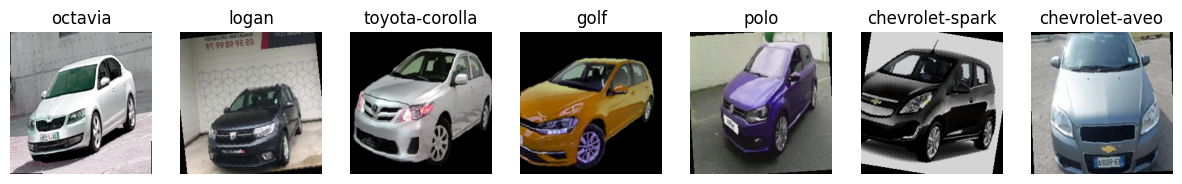

In [47]:
# TRAIN SET SAMPLE VISUALIZATION
plot_loader_data(train_loader)

Image size:  torch.Size([3, 224, 224])


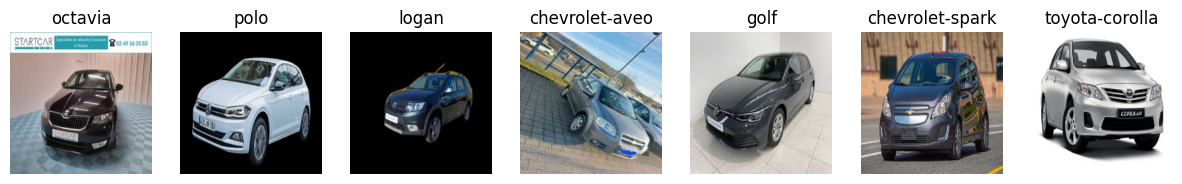

In [48]:
# TEST SET SAMPLE VISUALIZATION
plot_loader_data(test_loader)

In [49]:
class ClassifierCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.conv5 = nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(512)
        
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.5)
        
        self.fc1 = nn.Linear(512 * (IMAGE_SIZE // 32) * (IMAGE_SIZE // 32), 512)
        self.bnfc = nn.BatchNorm1d(512)
        self.fc2 = nn.Linear(512, len(SELECTED_CLASSES))
    
    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x)))) # 224 -> 112
        x = self.pool(F.relu(self.bn2(self.conv2(x)))) # 112 -> 56
        x = self.pool(F.relu(self.bn3(self.conv3(x)))) # 56 -> 28
        x = self.pool(F.relu(self.bn4(self.conv4(x)))) # 28 -> 14
        x = self.pool(F.relu(self.bn5(self.conv5(x)))) # 14 -> 7
        
        x = x.view(x.size(0), -1)  # flatten
        
        x = self.dropout(F.relu(self.bnfc(self.fc1(x))))
        x = self.fc2(x)
        
        return x

In [50]:
class SequentialClassifierCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # 224 -> 112
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # 112 -> 56
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # 56 -> 28
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # 28 -> 14
            
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # 14 -> 7
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * (IMAGE_SIZE // 32) * (IMAGE_SIZE // 32), 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, len(SELECTED_CLASSES))
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [51]:
class DumbCNN(nn.Module):
    # CNN is made to prove a case of overfitting, where more 
    # neurons and layers are required to fit the training data
    # correctly and prevent early plateauing of test accuracy
    
    def __init__(self):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # 224 -> 112
            
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # 112 -> 56
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # 56 -> 28
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * (IMAGE_SIZE // 8) * (IMAGE_SIZE // 8), 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, len(SELECTED_CLASSES))
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [52]:
# ---------------------  TRAINING HELPERS  --------------------
def evaluate(model, loader, criterion):
    model.eval()
    
    running_loss = 0.0
    running_correct = 0
    total_samples = 0
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Metrics
            batch_size = inputs.size(0)
            running_loss += loss.item() * batch_size
            
            _, preds = torch.max(outputs, 1)
            running_correct += torch.sum(preds == labels.data).item()
            total_samples += batch_size
    
    avg_loss = running_loss / total_samples
    accuracy = 100.0 * running_correct / total_samples
    
    return avg_loss, accuracy

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    
    running_loss = 0.0
    running_correct = 0
    total_samples = 0

    for inputs, labels in loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        batch_size = inputs.size(0)
        running_loss += loss.item() * batch_size 
        
        _, preds = torch.max(outputs, 1)
        running_correct += torch.sum(preds == labels.data).item()
        total_samples += batch_size

    epoch_loss = running_loss / total_samples
    epoch_acc = 100.0 * running_correct / total_samples
    
    return epoch_loss, epoch_acc

def validate(model, loader, crit):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            loss = crit(out, y)
            running_loss += loss.item()
    return running_loss / len(loader)
    
# --------------------------------------------------------------

In [53]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(model, loader, class_names, model_name="Model"):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            out = model(x)
            preds = out.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.numpy())
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.show()

def plot_training_history(h, model_name="Model"):
    ep = range(1, len(h["train_loss"]) + 1)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(ep, h["train_loss"], label="train")
    plt.plot(ep, h["dev_loss"],   label="dev")
    plt.title(f"{model_name} - Loss"); plt.xlabel("Epoch"); plt.legend(); plt.grid()
    plt.subplot(1,2,2)
    plt.plot(ep, h["train_acc"], label="train")
    plt.plot(ep, h["dev_acc"],   label="dev")
    plt.title(f"{model_name} - Accuracy (%)"); plt.xlabel("Epoch"); plt.legend(); plt.grid()
    plt.tight_layout(); plt.show()

In [54]:
def train_model(ModelClass, transfer_learning=False):
    if transfer_learning:
        model = ModelClass.to(DEVICE)
        print("Training via Transfer Learning")
    else:
        model = ModelClass().to(DEVICE)
    
    print("Training model:", model.__class__.__name__)
    
    lr_ratio = TRANSFER_LR if transfer_learning else BASE_LR
    model_epochs = EPOCHS_TL if transfer_learning else EPOCHS_BASE
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.Adam(model.parameters(), lr=lr_ratio, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=model_epochs)

    history = {"train_loss": [], "train_acc": [], "dev_loss": [], "dev_acc": []}
    optimizer.zero_grad()

    best_dev_loss = float('inf')
    wait = 0

    start_time = time.time()
    print("Starting training at: ", time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(start_time)))
    
    for epoch in range(1, model_epochs + 1):
        epoch_start = time.time()
        
        if epoch <= WARMPUP_EPOCHS:
            lr = lr_ratio * (epoch / WARMPUP_EPOCHS)
            for param_group in optimizer.param_groups:
                param_group['lr'] = lr

        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        
        if epoch > WARMPUP_EPOCHS:
            scheduler.step()
            
        dev_loss, dev_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["dev_loss"].append(dev_loss)
        history["dev_acc"].append(dev_acc)

        epoch_time = time.time() - epoch_start
        
        if epoch % 5 == 0:
            print(f"[Epoch {epoch:02d} | LR] Current LR:", optimizer.param_groups[0]['lr'])
        
        if dev_loss < best_dev_loss:
            best_dev_loss = dev_loss
            torch.save(model.state_dict(), f'models/{model.__class__.__name__}_best_model.pth')
            wait = 0
        else:
            wait += 1

        print(f"[Epoch {epoch:02d} | {timedelta(seconds=int(epoch_time))} ({epoch_time:.2f}s) | p={wait}/{PATIENCE}] "
            f"train_loss: {tr_loss:.3f} | train_acc: {tr_acc:5.2f}% | "
            f"dev_loss: {dev_loss:.3f} | dev_acc: {dev_acc:5.2f}%")

        if wait >= PATIENCE:
            print(f"Early stopping triggered at epoch {epoch}.")
            break

    total_time = time.time() - start_time
    print(f"\n=== TOTAL TRAINING TIME: {timedelta(seconds=int(total_time))} ({total_time:.2f}s) ===")

    print("\nLoading best model for final testing...")
    model.load_state_dict(torch.load(f'models/{model.__class__.__name__}_best_model.pth'))
    test_loss, test_acc = evaluate(model, test_loader, criterion)
    print(f"=== FINAL TEST ACCURACY: {test_acc:.2f}% ===")

    plot_training_history(history, model_name=model.__class__.__name__)
    plot_confusion_matrix(model, test_loader, SELECTED_CLASSES, model_name=model.__class__.__name__)

Training model: ClassifierCNN
Starting training at:  2025-12-05 20:43:21
[Epoch 01 | 0:00:08 (8.04s) | p=0/8] train_loss: 1.966 | train_acc: 24.96% | dev_loss: 2.209 | dev_acc: 21.71%
[Epoch 02 | 0:00:07 (7.95s) | p=1/8] train_loss: 1.707 | train_acc: 36.03% | dev_loss: 3.078 | dev_acc: 26.32%
[Epoch 03 | 0:00:07 (7.77s) | p=2/8] train_loss: 1.651 | train_acc: 41.98% | dev_loss: 2.430 | dev_acc: 36.18%
[Epoch 04 | 0:00:08 (8.24s) | p=3/8] train_loss: 1.448 | train_acc: 52.89% | dev_loss: 3.060 | dev_acc: 27.63%
[Epoch 05 | LR] Current LR: 0.000996057350657239
[Epoch 05 | 0:00:07 (7.84s) | p=0/8] train_loss: 1.315 | train_acc: 57.52% | dev_loss: 1.800 | dev_acc: 43.42%
[Epoch 06 | 0:00:07 (7.35s) | p=0/8] train_loss: 1.253 | train_acc: 63.14% | dev_loss: 1.481 | dev_acc: 54.61%
[Epoch 07 | 0:00:07 (7.48s) | p=0/8] train_loss: 1.140 | train_acc: 67.77% | dev_loss: 1.201 | dev_acc: 65.13%
[Epoch 08 | 0:00:07 (7.45s) | p=1/8] train_loss: 1.057 | train_acc: 72.56% | dev_loss: 1.326 | dev_ac

C:\Users\felixmv\AppData\Local\Temp\ipykernel_1280\1210695376.py:69: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'models/{model.__class__

=== FINAL TEST ACCURACY: 96.84% ===


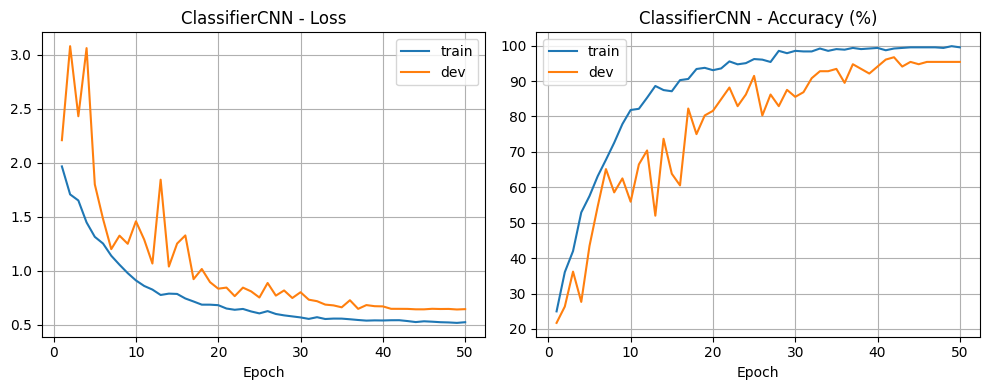

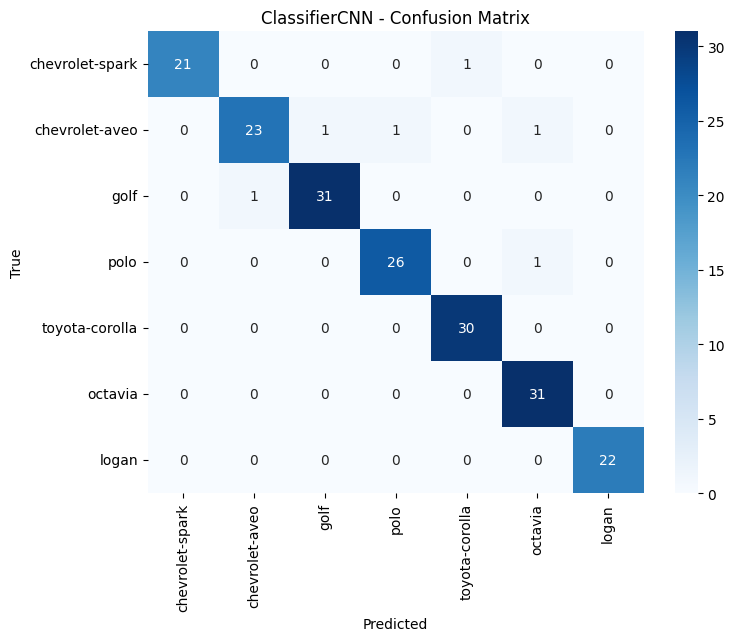

In [55]:
# --------------------------  TRAIN  ---------------------------
train_model(ClassifierCNN)

Training model: SequentialClassifierCNN
Starting training at:  2025-12-05 20:49:25
[Epoch 01 | 0:00:08 (8.14s) | p=0/8] train_loss: 1.922 | train_acc: 25.12% | dev_loss: 2.113 | dev_acc: 19.08%
[Epoch 02 | 0:00:07 (7.29s) | p=0/8] train_loss: 1.697 | train_acc: 39.67% | dev_loss: 1.821 | dev_acc: 38.82%
[Epoch 03 | 0:00:07 (7.09s) | p=1/8] train_loss: 1.535 | train_acc: 46.61% | dev_loss: 2.857 | dev_acc: 26.32%
[Epoch 04 | 0:00:07 (7.89s) | p=0/8] train_loss: 1.433 | train_acc: 51.57% | dev_loss: 1.518 | dev_acc: 53.29%
[Epoch 05 | LR] Current LR: 0.000996057350657239
[Epoch 05 | 0:00:07 (7.18s) | p=1/8] train_loss: 1.335 | train_acc: 57.85% | dev_loss: 1.827 | dev_acc: 44.08%
[Epoch 06 | 0:00:07 (7.07s) | p=2/8] train_loss: 1.200 | train_acc: 67.60% | dev_loss: 1.813 | dev_acc: 42.11%
[Epoch 07 | 0:00:06 (6.84s) | p=0/8] train_loss: 1.073 | train_acc: 72.56% | dev_loss: 1.270 | dev_acc: 61.84%
[Epoch 08 | 0:00:06 (6.89s) | p=1/8] train_loss: 1.053 | train_acc: 74.05% | dev_loss: 1.37

C:\Users\felixmv\AppData\Local\Temp\ipykernel_1280\1210695376.py:69: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'models/{model.__class__

=== FINAL TEST ACCURACY: 93.68% ===


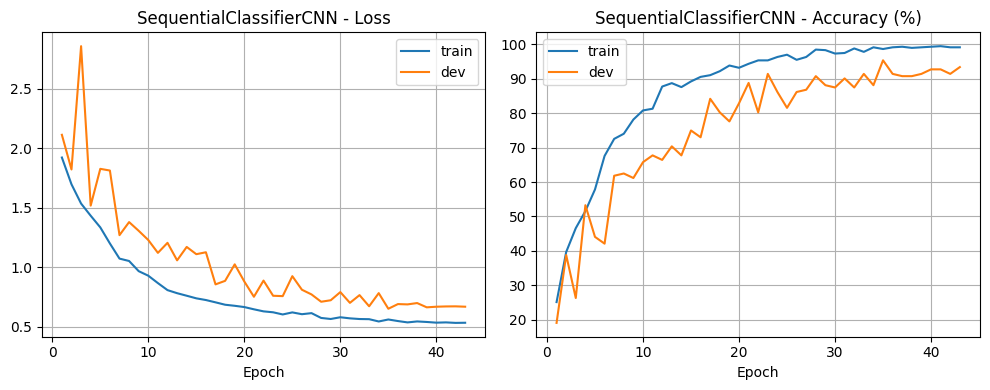

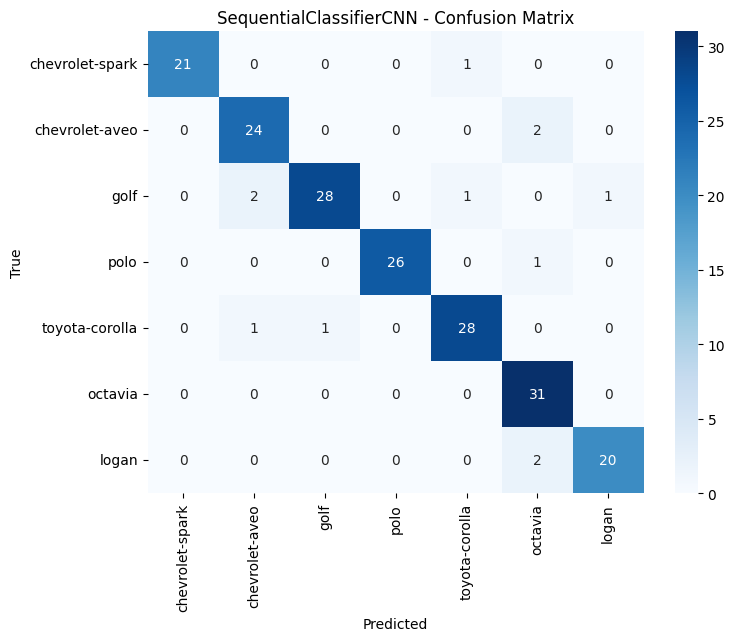

In [56]:
train_model(SequentialClassifierCNN)

Training model: DumbCNN
Starting training at:  2025-12-05 20:54:29
[Epoch 01 | 0:00:06 (6.98s) | p=0/8] train_loss: 2.049 | train_acc: 23.80% | dev_loss: 1.958 | dev_acc: 23.68%
[Epoch 02 | 0:00:06 (6.73s) | p=0/8] train_loss: 1.737 | train_acc: 36.36% | dev_loss: 1.744 | dev_acc: 34.87%
[Epoch 03 | 0:00:06 (6.48s) | p=0/8] train_loss: 1.617 | train_acc: 39.67% | dev_loss: 1.676 | dev_acc: 38.82%
[Epoch 04 | 0:00:06 (6.64s) | p=0/8] train_loss: 1.535 | train_acc: 47.60% | dev_loss: 1.608 | dev_acc: 44.74%
[Epoch 05 | LR] Current LR: 0.000996057350657239
[Epoch 05 | 0:00:06 (6.60s) | p=0/8] train_loss: 1.495 | train_acc: 49.59% | dev_loss: 1.557 | dev_acc: 44.74%
[Epoch 06 | 0:00:07 (7.03s) | p=0/8] train_loss: 1.413 | train_acc: 52.56% | dev_loss: 1.509 | dev_acc: 48.68%
[Epoch 07 | 0:00:06 (6.29s) | p=1/8] train_loss: 1.360 | train_acc: 58.35% | dev_loss: 1.561 | dev_acc: 47.37%
[Epoch 08 | 0:00:05 (5.96s) | p=0/8] train_loss: 1.314 | train_acc: 58.84% | dev_loss: 1.403 | dev_acc: 53.

C:\Users\felixmv\AppData\Local\Temp\ipykernel_1280\1210695376.py:69: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'models/{model.__class__

=== FINAL TEST ACCURACY: 83.68% ===


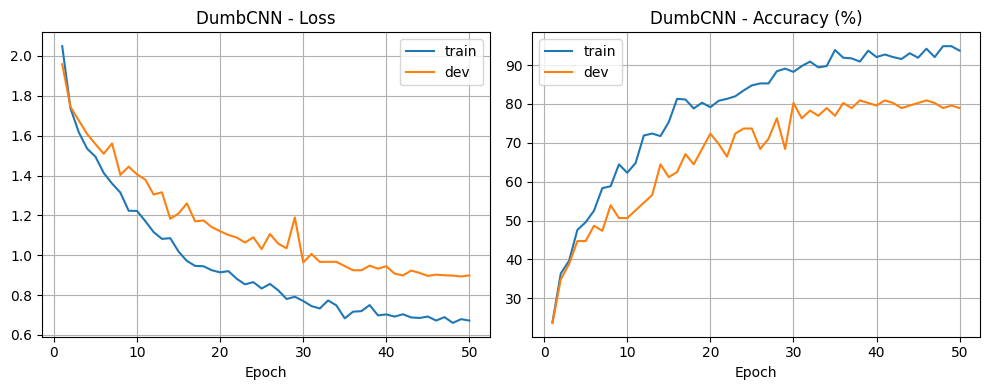

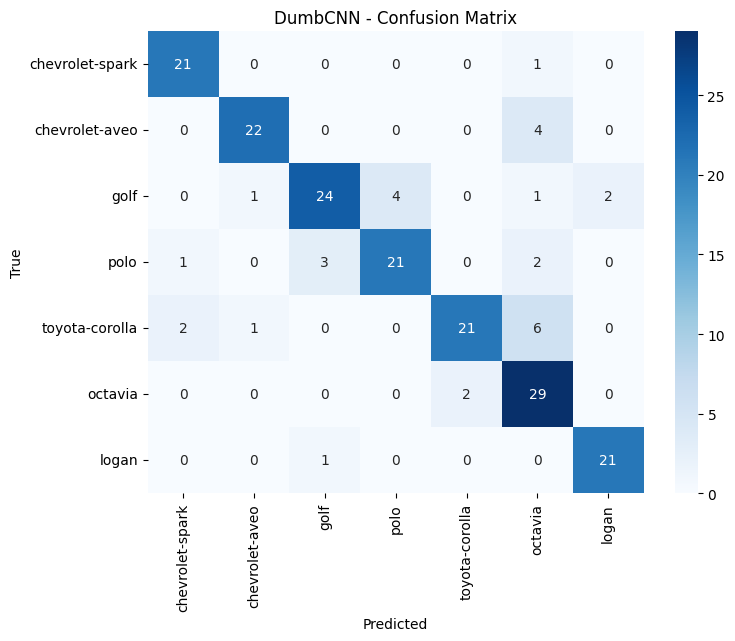

In [57]:
train_model(DumbCNN)

Training via Transfer Learning
Training model: ResNet
Starting training at:  2025-12-05 20:59:53
[Epoch 01 | 0:00:08 (8.61s) | p=0/8] train_loss: 2.053 | train_acc: 19.17% | dev_loss: 1.759 | dev_acc: 36.84%
[Epoch 02 | 0:00:08 (8.76s) | p=0/8] train_loss: 1.709 | train_acc: 40.17% | dev_loss: 1.461 | dev_acc: 49.34%
[Epoch 03 | 0:00:08 (8.45s) | p=0/8] train_loss: 1.296 | train_acc: 60.66% | dev_loss: 1.179 | dev_acc: 63.82%
[Epoch 04 | 0:00:08 (8.60s) | p=0/8] train_loss: 0.925 | train_acc: 81.16% | dev_loss: 0.880 | dev_acc: 78.95%
[Epoch 05 | LR] Current LR: 9.045084971874737e-05
[Epoch 05 | 0:00:08 (8.69s) | p=0/8] train_loss: 0.757 | train_acc: 88.93% | dev_loss: 0.749 | dev_acc: 84.21%
[Epoch 06 | 0:00:08 (8.38s) | p=0/8] train_loss: 0.668 | train_acc: 93.88% | dev_loss: 0.706 | dev_acc: 92.11%
[Epoch 07 | 0:00:08 (8.16s) | p=0/8] train_loss: 0.615 | train_acc: 96.03% | dev_loss: 0.642 | dev_acc: 92.11%
[Epoch 08 | 0:00:07 (7.60s) | p=1/8] train_loss: 0.585 | train_acc: 97.19% |

C:\Users\felixmv\AppData\Local\Temp\ipykernel_1280\1210695376.py:69: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'models/{model.__class__

=== FINAL TEST ACCURACY: 96.84% ===


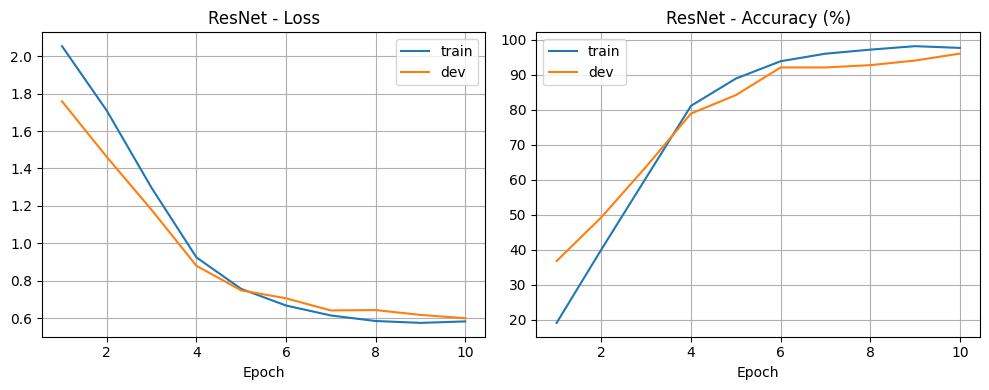

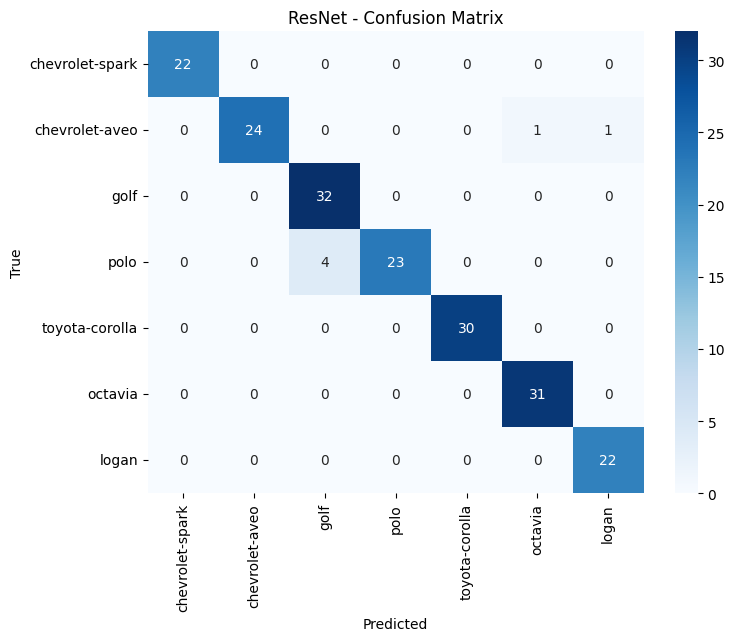

In [58]:
# -------------------- VIA TRANSFER LEARNING --------------------
pretrained_model = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
num_ftrs = pretrained_model.fc.in_features
pretrained_model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_ftrs, len(SELECTED_CLASSES))  # ajustar la capa final
)

train_model(pretrained_model, transfer_learning=True)